# 🌸 鸢尾花 (Iris) 预测神经网络设计与实现

基于 **花萼长度**、**花萼宽度**、**花瓣长度**、**花瓣宽度** 这 4 个特征，设计一个带 **单个隐藏层**、使用 **ReLU 激活函数** 和 **交叉熵损失函数** 的神经网络来进行分类预测。

### 📐 网络结构参数定义
- **输入维数 (Input Dim)**: 4 (花萼长度, 花萼宽度, 花瓣长度, 花瓣宽度)
- **隐藏层维数 (Hidden Dim)**: 16 (激活函数: ReLU)
- **输出维数 (Output Dim)**: 3 (对应 setosa, versicolor, virginica 三种分类)
- **损失函数 (Loss Function)**: 交叉熵损失 (Cross Entropy Loss)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 设置绘图参数与中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. 加载 Iris 数据集
iris = load_iris()
X = iris.data    # 4维特征：花萼长度, 花萼宽度, 花瓣长度, 花瓣宽度
y = iris.target  # 标签：0 (setosa), 1 (versicolor), 2 (virginica)
feature_names = iris.feature_names
target_names = iris.target_names

# 2. 数据切分 (80% 训练集, 20% 测试集)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 特征标准化 (Z-score 标准化，使每个特征均值为 0，方差为 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"特征列表: {feature_names}")
print(f"类别列表: {target_names}")
print(f"训练集形状: {X_train_scaled.shape}, 测试集形状: {X_test_scaled.shape}")

特征列表: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别列表: ['setosa' 'versicolor' 'virginica']
训练集形状: (120, 4), 测试集形状: (30, 4)


## 🚀 2. PyTorch 神经网络实现 (输入 4 -> 隐藏层 16, ReLU -> 输出 3, 交叉熵)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# 设置固定随机种子以保证实验可复现
torch.manual_seed(42)
np.random.seed(42)

# 将 Numpy 数组转换为 PyTorch Tensor 张量
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# 定义单隐藏层神经网络结构
class IrisNN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=3):
        super(IrisNN, self).__init__()
        # 全连接隐藏层：连接 4 个输入特征与 16 个隐藏神经元
        self.hidden = nn.Linear(input_dim, hidden_dim)
        # ReLU 激活函数
        self.relu = nn.ReLU()
        # 全连接输出层：将 16 个隐藏神经元映射为 3 个类别的 Logits
        self.output = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        x = self.hidden(x)   # 1. 隐藏层线性变换: Z1 = X * W1 + b1
        x = self.relu(x)     # 2. ReLU 激活函数: A1 = max(0, Z1)
        x = self.output(x)   # 3. 输出层线性变换: Z2 = A1 * W2 + b2
        return x             # 注：PyTorch nn.CrossEntropyLoss 会自动包含 Softmax 运算

# 实例化模型
model = IrisNN(input_dim=4, hidden_dim=16, output_dim=3)
print("模型结构设计:\n", model)

模型结构设计:
 IrisNN(
  (hidden): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=16, out_features=3, bias=True)
)


In [3]:
# 定义损失函数与优化器
criterion = nn.CrossEntropyLoss()                  # 交叉熵损失函数
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adam 优化器，学习率设为 0.01

# 模型训练循环
epochs = 200
loss_history = []
acc_history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()  # 梯度清零，防止梯度累积
    
    # 前向传播
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    # 反向传播与梯度更新
    loss.backward()
    optimizer.step()
    
    # 记录 Loss 与 Acc
    loss_history.append(loss.item())
    preds = torch.argmax(outputs, dim=1)
    acc = (preds == y_train_t).float().mean().item()
    acc_history.append(acc)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:03d}/{epochs}] - Loss: {loss.item():.4f} - Train Acc: {acc*100:.2f}%")

Epoch [020/200] - Loss: 0.3695 - Train Acc: 90.83%
Epoch [040/200] - Loss: 0.1923 - Train Acc: 94.17%
Epoch [060/200] - Loss: 0.1063 - Train Acc: 97.50%
Epoch [080/200] - Loss: 0.0724 - Train Acc: 97.50%
Epoch [100/200] - Loss: 0.0590 - Train Acc: 97.50%
Epoch [120/200] - Loss: 0.0525 - Train Acc: 97.50%
Epoch [140/200] - Loss: 0.0488 - Train Acc: 98.33%
Epoch [160/200] - Loss: 0.0463 - Train Acc: 98.33%
Epoch [180/200] - Loss: 0.0445 - Train Acc: 98.33%
Epoch [200/200] - Loss: 0.0432 - Train Acc: 98.33%


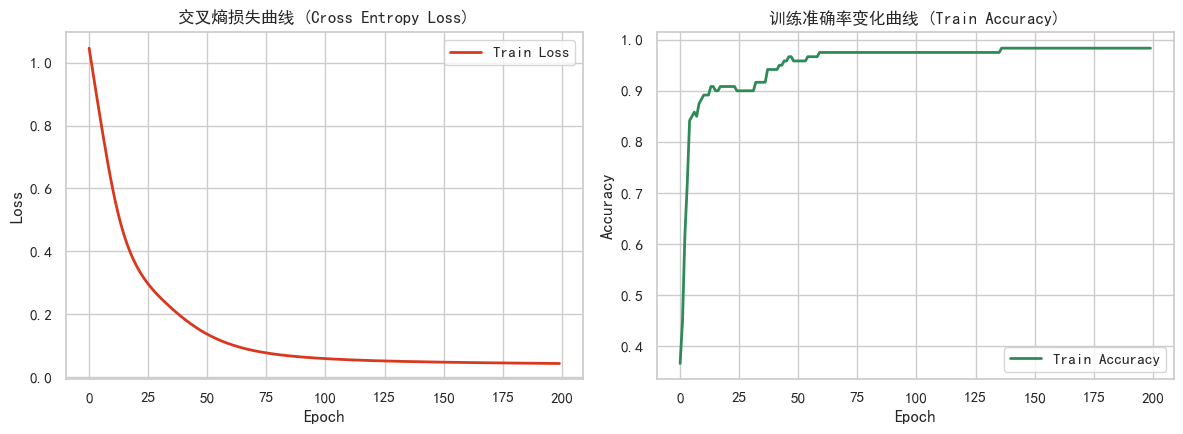

In [4]:
# 绘制 Loss 及 Accuracy 变化曲线
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Train Loss', color='#D9381E', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('交叉熵损失曲线 (Cross Entropy Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_history, label='Train Accuracy', color='#2E8B57', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('训练准确率变化曲线 (Train Accuracy)')
plt.legend()

plt.tight_layout()
plt.show()

🎯 测试集准确率 (Test Accuracy): 100.00%

分类评估报告:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



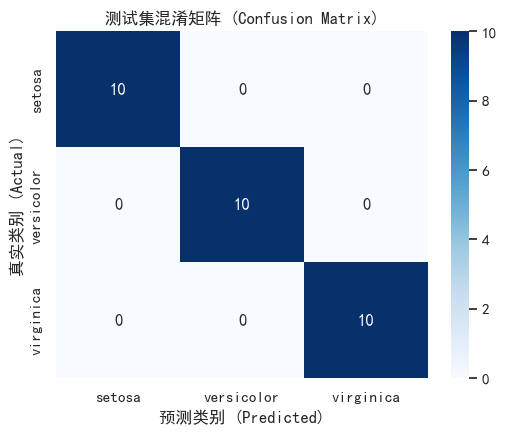

In [5]:
# 在测试集上评估模型表现
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    test_preds = torch.argmax(test_outputs, dim=1).numpy()

test_acc = accuracy_score(y_test, test_preds)
print(f"🎯 测试集准确率 (Test Accuracy): {test_acc*100:.2f}%")
print("\n分类评估报告:\n", classification_report(y_test, test_preds, target_names=target_names))

# 混淆矩阵可视化
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('测试集混淆矩阵 (Confusion Matrix)')
plt.xlabel('预测类别 (Predicted)')
plt.ylabel('真实类别 (Actual)')
plt.show()

--- 
## 💡 3. 底层推导实现：纯 NumPy 手写单隐藏层神经网络 (含前向/反向传播)

不依赖深度学习框架，使用 `NumPy` 手写推导与求导公式：
- 前向传播: $Z_1 = X W_1 + b_1 \to A_1 = \max(0, Z_1) \to Z_2 = A_1 W_2 + b_2 \to P = \text{Softmax}(Z_2)$
- 交叉熵损失: $L = -\frac{1}{N} \sum Y \cdot \log(P)$
- 反向传播: $dZ_2 = \frac{P - Y}{N}, \quad dW_2 = A_1^T dZ_2, \quad dZ_1 = (dZ_2 W_2^T) \odot \mathbb{I}(Z_1 > 0), \quad dW_1 = X^T dZ_1$

In [6]:
class NeuralNetworkNumPy:
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=3, seed=42):
        np.random.seed(seed)
        # He 参数初始化 (针对 ReLU 激活函数优化)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
    def relu(self, Z):
        return np.maximum(0, Z)
    
    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True)) # 减去最大值，防止指数上溢
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
    
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.probs = self.softmax(self.Z2)
        return self.probs
    
    def compute_loss(self, probs, Y_onehot):
        N = probs.shape[0]
        probs_clipped = np.clip(probs, 1e-15, 1.0 - 1e-15) # 剪切边界防止 log(0) NaN 错误
        loss = -np.sum(Y_onehot * np.log(probs_clipped)) / N
        return loss
    
    def backward(self, X, Y_onehot, lr=0.05):
        N = X.shape[0]
        
        # 链式法则求导梯度
        dZ2 = (self.probs - Y_onehot) / N
        dW2 = np.dot(self.A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)
        
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.Z1 > 0).astype(float) # ReLU 导数
        dW1 = np.dot(X.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)
        
        # 梯度下降更新权重参数
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

In [7]:
# 训练与评估 NumPy 版本神经网络
Y_train_onehot = np.eye(3)[y_train]
nn_numpy = NeuralNetworkNumPy(input_dim=4, hidden_dim=16, output_dim=3)

for epoch in range(300):
    probs = nn_numpy.forward(X_train_scaled)
    loss = nn_numpy.compute_loss(probs, Y_train_onehot)
    nn_numpy.backward(X_train_scaled, Y_train_onehot, lr=0.05)

np_preds = nn_numpy.predict(X_test_scaled)
np_acc = accuracy_score(y_test, np_preds)
print(f"✨ NumPy 手写神经网络测试集准确率: {np_acc*100:.2f}%")

✨ NumPy 手写神经网络测试集准确率: 86.67%


--- 
## 🔍 4. 单样本特征分类预测接口

In [8]:
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):
    """
    输入花萼长度、花萼宽度、花瓣长度、花瓣宽度，输出模型预测概率与类别
    """
    # 1. 组装输入特征并做标准化
    raw_input = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    scaled_input = scaler.transform(raw_input)
    
    # 2. PyTorch 模型推理
    input_tensor = torch.tensor(scaled_input, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probabilities = torch.softmax(logits, dim=1).numpy()[0]
        predicted_class_id = np.argmax(probabilities)
        predicted_class_name = target_names[predicted_class_id]
    
    # 3. 输出格式化预测结果
    print(f"🌸 输入测量特征 -> 花萼长: {sepal_length}cm, 花萼宽: {sepal_width}cm, 花瓣长: {petal_length}cm, 花瓣宽: {petal_width}cm")
    print(f"👉 预测鸢尾花类别: 【{predicted_class_name}】 (类别ID: {predicted_class_id})")
    print("📊 各类别所属概率分布:")
    for i, name in enumerate(target_names):
        print(f"   - {name:12s}: {probabilities[i]*100:.2f}%")

# 测试样本 1: setosa 特征示例 (花萼长=5.1, 花萼宽=3.5, 花瓣长=1.4, 花瓣宽=0.2)
predict_flower(sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2)
print("-" * 60)
# 测试样本 2: virginica 特征示例 (花萼长=6.7, 花萼宽=3.0, 花瓣长=5.2, 花瓣宽=2.3)
predict_flower(sepal_length=6.7, sepal_width=3.0, petal_length=5.2, petal_width=2.3)

🌸 输入测量特征 -> 花萼长: 5.1cm, 花萼宽: 3.5cm, 花瓣长: 1.4cm, 花瓣宽: 0.2cm
👉 预测鸢尾花类别: 【setosa】 (类别ID: 0)
📊 各类别所属概率分布:
   - setosa      : 99.99%
   - versicolor  : 0.01%
   - virginica   : 0.00%
------------------------------------------------------------
🌸 输入测量特征 -> 花萼长: 6.7cm, 花萼宽: 3.0cm, 花瓣长: 5.2cm, 花瓣宽: 2.3cm
👉 预测鸢尾花类别: 【virginica】 (类别ID: 2)
📊 各类别所属概率分布:
   - setosa      : 0.00%
   - versicolor  : 0.02%
   - virginica   : 99.98%
